In [2]:
import sys
print("Python:", sys.version.split()[0])
print("Exécutable:", sys.executable)   # doit contenir venv-pneumonia

import numpy as np
import pandas as pd
import matplotlib
import seaborn as sns
import sklearn
import PIL
import cv2
import tensorflow as tf
import kagglehub          # on garde kagglehub, on enlève "import kaggle"

print("\n--- Versions ---")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("TensorFlow:", tf.__version__)
print("GPU détecté:", tf.config.list_physical_devices('GPU'))

Python: 3.12.3
Exécutable: /home/floflo/venv-pneumonia/bin/python


2026-06-18 16:25:45.128747: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-18 16:25:46.199820: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



--- Versions ---
NumPy: 1.26.4
Pandas: 3.0.3
scikit-learn: 1.9.0
OpenCV: 4.13.0
TensorFlow: 2.16.1
GPU détecté: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-06-18 16:25:47.636190: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:26:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 16:25:47.807881: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:26:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-18 16:25:47.807967: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:26:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("OK, données dans :", path)

OK, données dans : /home/floflo/.cache/kagglehub/datasets/paultimothymooney/chest-xray-pneumonia/versions/2


In [4]:
import os 
BASE_DIR = os.path.join(path, "chest_xray")

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

for nom, d in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(nom, "->", os.listdir(d))


TRAIN -> ['PNEUMONIA', 'NORMAL']
VAL -> ['PNEUMONIA', 'NORMAL']
TEST -> ['PNEUMONIA', 'NORMAL']


In [7]:
def compter_images(dossier):
    """
    Compte le nombre d'images dans les sous-dossiers NORMAL et PNEUMONIA.

    Paramètre
    ---------
    dossier : str
        Chemin vers un split (train, val ou test).

    Retour
    ------
    dict : {'NORMAL': int, 'PNEUMONIA': int}
    """
    counts = {}
    for classe in ["NORMAL", "PNEUMONIA"]:
        chemin_classe = os.path.join(dossier, classe)
        counts[classe] = len(os.listdir(chemin_classe))
    return counts

In [8]:
for nom, dossier in [("TRAIN", TRAIN_DIR), ("VAL", VAL_DIR), ("TEST", TEST_DIR)]:
    print(nom, ":", compter_images(dossier))

TRAIN : {'NORMAL': 1341, 'PNEUMONIA': 3875}
VAL : {'NORMAL': 8, 'PNEUMONIA': 8}
TEST : {'NORMAL': 234, 'PNEUMONIA': 390}


#### La repartition de TRAIN est vraiment déséquilibré. Il faudra alors tirer attention sur l'accuracy qui ne sera pas le miroir de la réalité et sera trompeuse .
#### De plus, la partie VAL est ridiculement petit, par rapport au TRAIN. On va alors re-split pour que la distribution soit cohérente. 

 

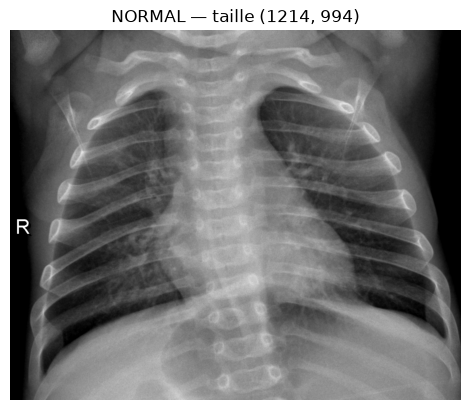

(1214, 994)

In [10]:
import matplotlib.pyplot as plt
from PIL import Image

def afficher_exemple(split_dir, classe):
    """
    Affiche la première image d'une classe donnée.

    Paramètres
    ----------
    split_dir : str
        Chemin d'un split (ex. TRAIN_DIR).
    classe : str
        "NORMAL" ou "PNEUMONIA".
    """
    # 1. Chemin du dossier de la classe
    chemin_classe = os.path.join(split_dir, classe)

    # 2. Liste des fichiers, on prend le premier
    fichiers = os.listdir(chemin_classe)
    premier_fichier = fichiers[0]   # le [0] = premier élément de la liste

    # 3. Chemin complet de l'image
    # TODO : assemble chemin_classe + premier_fichier avec os.path.join
    chemin_image = os.path.join(chemin_classe, premier_fichier)

    # 4. Ouvre l'image avec PIL
    img = Image.open(chemin_image)

    # 5. Affiche
    plt.imshow(img, cmap="gray")          # cmap="gray" car ce sont des radios N&B
    plt.title(f"{classe} — taille {img.size}")   # img.size = (largeur, hauteur)
    plt.axis("off")
    plt.show()

    # On retourne la taille pour info
    return img.size

# Appel : affiche une image NORMAL du train
# TODO : appelle afficher_exemple avec TRAIN_DIR et "NORMAL"
afficher_exemple(TRAIN_DIR, "NORMAL")

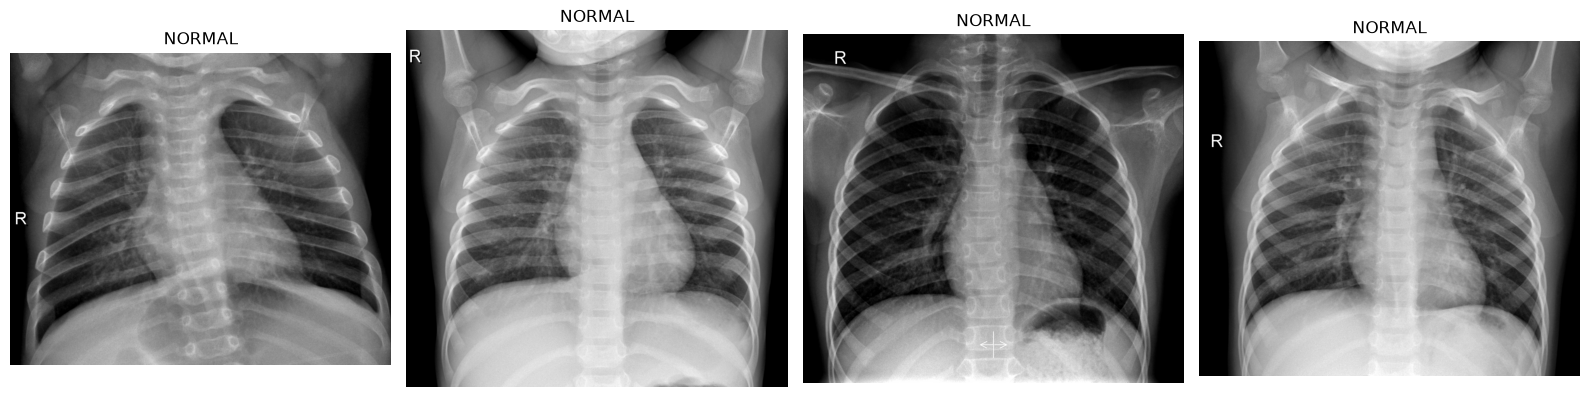

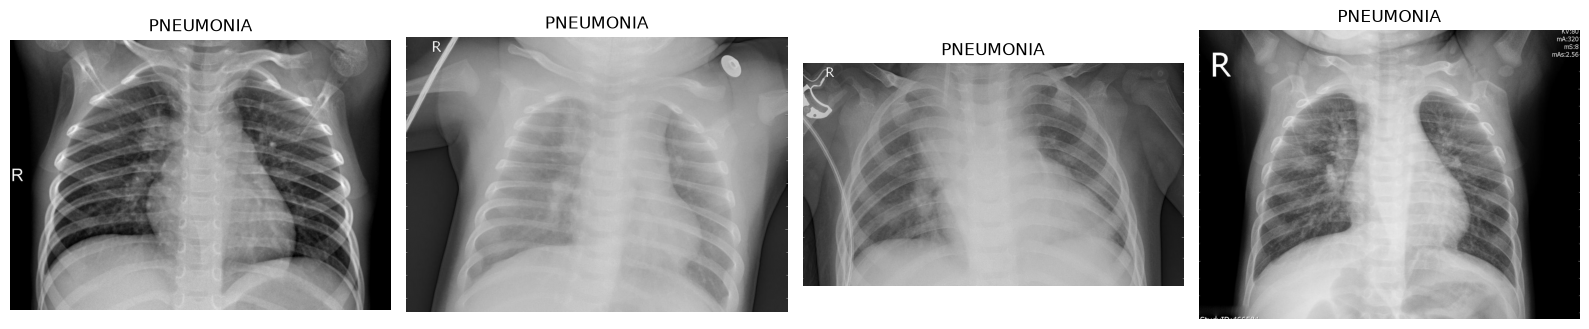

In [14]:
def afficher_grille(split_dir, classe, n=4):
    """
    Affiche les n premières images d'une classe sur une ligne.

    Paramètres
    ----------
    split_dir : str   -> chemin d'un split (ex. TRAIN_DIR)
    classe    : str   -> "NORMAL" ou "PNEUMONIA"
    n         : int   -> nombre d'images à afficher (défaut 4)
    """
    chemin_classe = os.path.join(split_dir, classe)
    fichiers = os.listdir(chemin_classe)[:n]   # [:n] = les n premiers fichiers

    # Crée une figure avec n sous-graphiques côte à côte
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))

    for i, fichier in enumerate(fichiers):
        chemin_image = os.path.join(chemin_classe, fichier)
        img = Image.open(chemin_image)
        axes[i].imshow(img, cmap="gray")          # cmap="gray" car ce sont des radios N&B
        axes[i].set_title(f"{classe}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Compare les deux classes
afficher_grille(TRAIN_DIR, "NORMAL", n=4)
afficher_grille(TRAIN_DIR, "PNEUMONIA", n=4)

#### La fonction ci-dessus affiche la difference entre 4 radio normales et 4 radio avec présence de pneumonie, afin de comparer visuallement ces deux ensemble de radio. 

#### L'inspection visuelle ne permet pas de distinguer aisément les deux classes pour un œil non expert, ce qui justifie l'approche par apprentissage automatique et souligne l'importance de l'interprétabilité (Grad-CAM) pour valider que le modèle s'appuie sur des régions cliniquement pertinentes.

In [ ]:
import numpy as np

def collecter_tailles(split_dir, n_par_classe=150):
    """
    Récupère les dimensions (largeur, hauteur) d'un échantillon d'images.

    Paramètres
    ----------
    split_dir    : str -> chemin d'un split (ex. TRAIN_DIR)
    n_par_classe : int -> nb d'images à inspecter par classe

    Retour
    ------
    largeurs, hauteurs : deux listes de nombres
    """
    largeurs = []
    hauteurs = []

    for classe in ["NORMAL", "PNEUMONIA"]:
        chemin_classe = os.path.join(split_dir, classe)
        fichiers = os.listdir(chemin_classe)[:n_par_classe]

        for fichier in fichiers:
            chemin_image = os.path.join(chemin_classe, fichier)
            img = Image.open(chemin_image)
            largeur, hauteur = img.size   # img.size renvoie (largeur, hauteur)
            # TODO : ajoute largeur à la liste largeurs
            # TODO : ajoute hauteur à la liste hauteurs
            #        Indice : maliste.append(valeur)

    return largeurs, hauteurs

largeurs, hauteurs = collecter_tailles(TRAIN_DIR)
print("Nombre d'images inspectées :", len(largeurs))
print("Largeur  -> min:", min(largeurs), " max:", max(largeurs), " moyenne:", round(np.mean(largeurs)))
print("Hauteur  -> min:", min(hauteurs), " max:", max(hauteurs), " moyenne:", round(np.mean(hauteurs)))